In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack
import fitsio
# from astropy.io import fits

sys.path.append(os.path.expanduser('~/git/desi-photoz/'))
import pz_modules

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

# Main LRGs

In [3]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/data/main/main-lrg-daily-thru20210615-add_pz.fits'))
print(len(cat))

291793


In [4]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['COADD_EFFTIME_GFA']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Remove not-done fibers
# mask = cat['ZDONE']==1
# cat = cat[mask]
# print('ZDONE   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))

FIBERSTATUS    3475 288318 0.011909127360834564
No data    0 288318 0.0
Min depth    4533 283785 0.015722223378353068


In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']) - 2.165 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [6]:
mask_quality0 = cat['ZWARN']==0
mask_quality0 &= cat['DELTACHI2']>15
mask_quality0 &= cat['Z']<1.4
print(np.sum(~mask_quality0)/len(mask_quality0))

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)
print(np.sum(~mask_quality)/len(mask_quality))

# Custom cut with DELTACHI2>15
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<15)
mask_quality1 = cat['ZWARN']==0
mask_quality1 &= cat['Z']<1.4
mask_quality1 &= (~mask_remove)
print(np.sum(~mask_quality1)/len(mask_quality1))

0.025473509875433866
0.023366280811177476
0.02730588297478725


In [7]:
cat = cat[mask_quality]
print(len(cat))

277154


In [8]:
# WISE and MEDIUM masks
maskbits = [8, 9, 11]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
cat = cat[mask_clean]

MASKBITS 255973 21181 0.9235767840262092


In [9]:
# Remove QSO targets
mask_qso = cat['DESI_TARGET'] & 2**2 > 0
print(np.sum(mask_qso)/len(cat))

cat = cat[~mask_qso]
print(len(cat))

0.013864743547170991
252424


In [10]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

76533 175891


Normalized MAD: 0.026053
0.10 outliers: 2.657037%


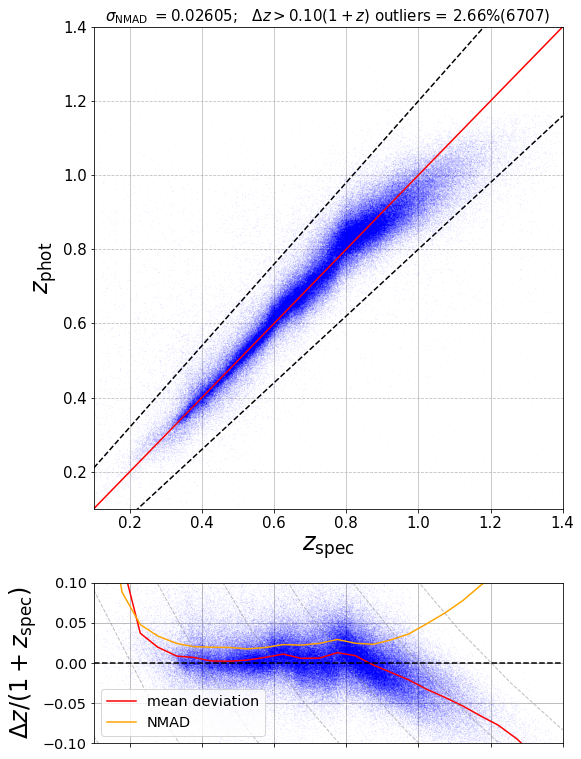

In [14]:
mask = np.full(len(cat), True)
pz_modules.plot_photoz_specz(cat['Z_PHOT_MEDIAN'][mask], cat['Z'][mask], markersize=0.1, zmin=0.1, zmax=1.4, verbose=False, alpha=0.3)

Normalized MAD: 0.025551
0.10 outliers: 2.605591%


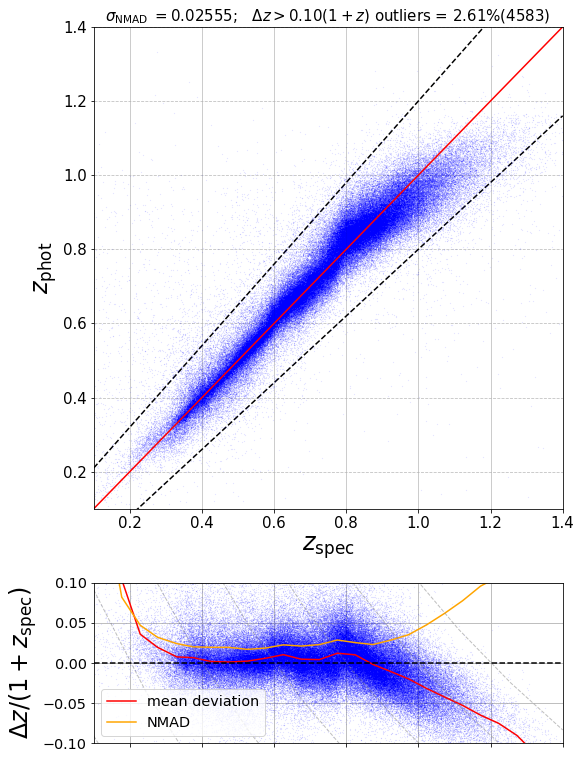

In [17]:
mask = mask_south.copy()
pz_modules.plot_photoz_specz(cat['Z_PHOT_MEDIAN'][mask], cat['Z'][mask], markersize=0.4, zmin=0.1, zmax=1.4, verbose=False)

Normalized MAD: 0.027231
0.10 outliers: 2.775273%


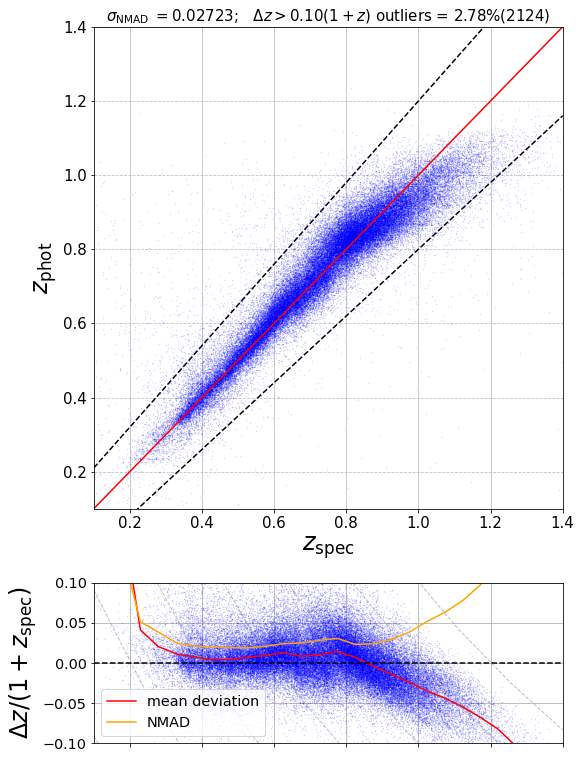

In [18]:
mask = mask_north.copy()
pz_modules.plot_photoz_specz(cat['Z_PHOT_MEDIAN'][mask], cat['Z'][mask], markersize=0.7, zmin=0.1, zmax=1.4, verbose=False)

# SV1 LRGs

In [100]:
cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/testdenali_alltiles_Allzinfo_LRG_pz_added.fits'))
print(len(cat))
print(len(np.unique(cat['TARGETID'])))

52268
52023


In [101]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['rfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_R']) - 2.165 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [102]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the deep coadd
min_depth = 2000.
mask = cat['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]

print(len(cat))

FIBERSTATUS 43371 8897 0.17021887196755184
No data 43368 3 6.917064397869545e-05
Min depth 36843 6525 0.8495434421693414
36843


In [103]:
mask_quality0 = cat['ZWARN']==0
mask_quality0 &= cat['DELTACHI2']>15
mask_quality0 &= cat['Z']<1.4
print(np.sum(~mask_quality0)/len(mask_quality0))

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)
print(np.sum(~mask_quality)/len(mask_quality))

cat = cat[mask_quality]
print(len(cat))

0.025893656868333198
0.024943679939201477
35924


In [104]:
# WISE and MEDIUM masks
maskbits = [8, 9, 11]
mask_clean = np.ones(len(cat), dtype=bool)
for bit in maskbits:
    mask_clean &= (cat['MASKBITS'] & 2**bit)==0
print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
cat = cat[mask_clean]

MASKBITS 33210 2714 0.92445162008685


In [105]:
# mask_zfib = cat['zfibermag']<21.8
# print(np.sum(mask_zfib)/len(mask))

# Select LRG_SV_IR
sv_ir = cat['SV1_DESI_TARGET'] & 2**6 > 0
print(np.sum(sv_ir)/len(sv_ir))
cat = cat[sv_ir]

# mask = mask_zfib & sv_ir
# print(np.sum(mask))
# cat = cat[mask]

0.8660945498343873


In [106]:
# Remove QSO targets
mask_qso = cat['SV1_DESI_TARGET'] & 2**2 > 0
print(np.sum(mask_qso)/len(cat))

cat = cat[~mask_qso]
print(len(cat))

0.0356708271042659
27737


In [107]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'
print(np.sum(mask_north), np.sum(mask_south))

12929 14808


Normalized MAD: 0.031866
0.10 outliers: 4.463352%


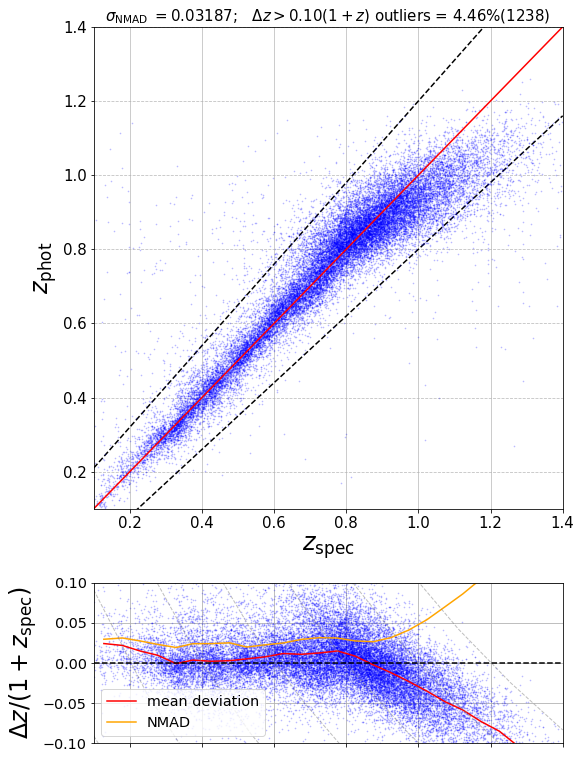

In [108]:
mask = np.full(len(cat), True)
pz_modules.plot_photoz_specz(cat['Z_PHOT_MEDIAN'][mask], cat['Z'][mask], markersize=1.5, zmin=0.1, zmax=1.4, verbose=False)

Normalized MAD: 0.025724
0.10 outliers: 2.682256%


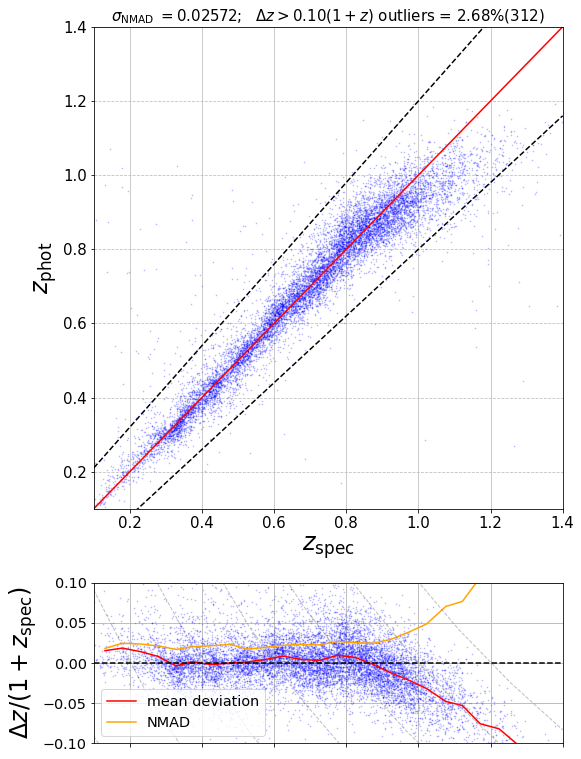

In [92]:
mask = mask_south.copy()
pz_modules.plot_photoz_specz(cat['Z_PHOT_MEDIAN'][mask], cat['Z'][mask], markersize=1.5, zmin=0.1, zmax=1.4, verbose=False)

Normalized MAD: 0.030991
0.10 outliers: 3.905256%


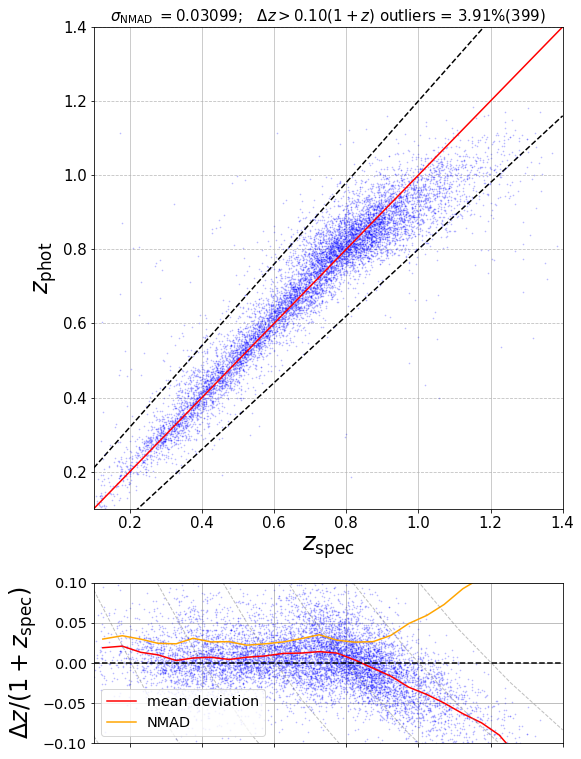

In [93]:
mask = mask_north.copy()
pz_modules.plot_photoz_specz(cat['Z_PHOT_MEDIAN'][mask], cat['Z'][mask], markersize=1.5, zmin=0.1, zmax=1.4, verbose=False)